# Queries Gold — Dashboard Market Share

Queries PySpark com visualizações para o dashboard Lakeview `Market Share Dashboard`.

In [0]:
import matplotlib.pyplot as plt
from pyspark.sql.functions import sum as spark_sum, round as _round, avg

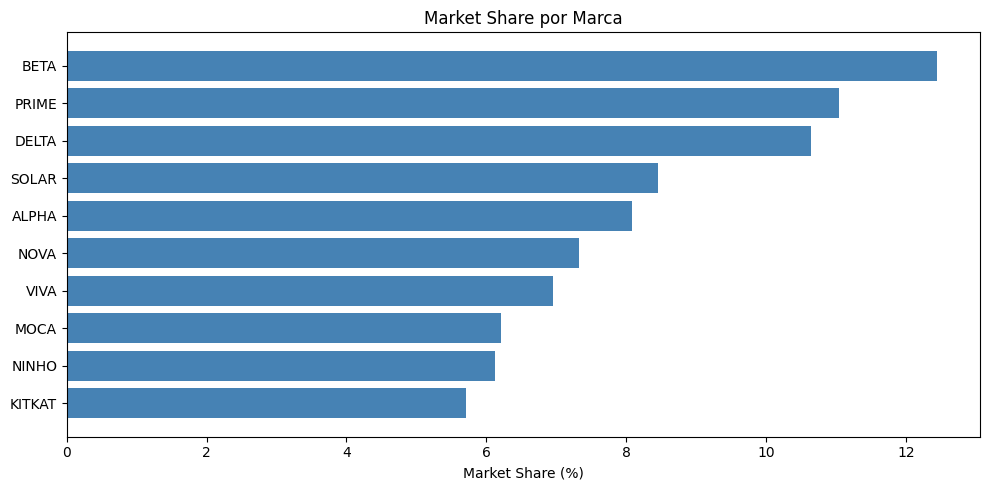

In [0]:
# Market Share por Marca (Bar Chart)
df_brand = (spark.table("dataquality_challenge.gold.market_share_by_brand")
    .filter("year_week = (SELECT MAX(year_week) FROM dataquality_challenge.gold.market_share_by_brand)")
    .select("brand", "market_share_pct")
    .orderBy("market_share_pct", ascending=False)
    .limit(10))
pdf = df_brand.toPandas()
plt.figure(figsize=(10, 5))
plt.barh(pdf["brand"], pdf["market_share_pct"], color="steelblue")
plt.xlabel("Market Share (%)")
plt.title("Market Share por Marca")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

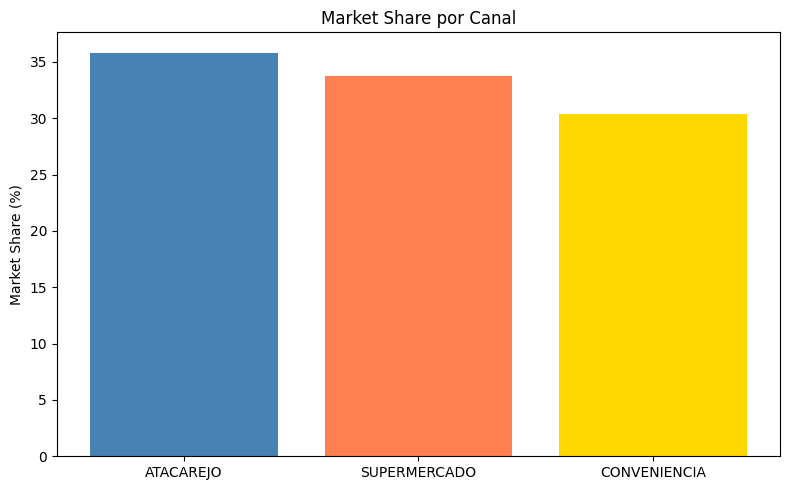

In [0]:
# Market Share por Canal (Bar Chart)
df_channel = (spark.table("dataquality_challenge.gold.market_share_by_channel")
    .filter("year_week = (SELECT MAX(year_week) FROM dataquality_challenge.gold.market_share_by_channel)")
    .select("channel", "market_share_pct")
    .orderBy("market_share_pct", ascending=False))
pdf = df_channel.toPandas()
plt.figure(figsize=(8, 5))
plt.bar(pdf["channel"], pdf["market_share_pct"], color=["steelblue", "coral", "gold"])
plt.ylabel("Market Share (%)")
plt.title("Market Share por Canal")
plt.tight_layout()
plt.show()

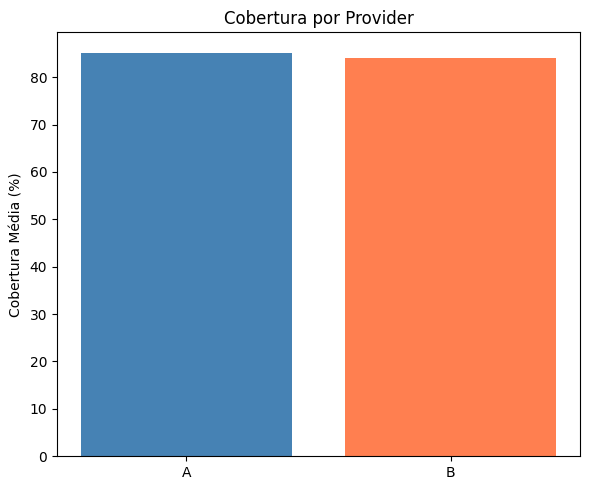

In [0]:
# Cobertura por Provider (Bar Chart)
df_coverage = (spark.table("dataquality_challenge.gold.coverage_metrics")
    .groupBy("provider")
    .agg(_round(avg("coverage_pct"), 1).alias("avg_coverage_pct"))
    .orderBy("provider"))
pdf = df_coverage.toPandas()
plt.figure(figsize=(6, 5))
plt.bar(pdf["provider"], pdf["avg_coverage_pct"], color=["steelblue", "coral"])
plt.ylabel("Cobertura Média (%)")
plt.title("Cobertura por Provider")
plt.tight_layout()
plt.show()

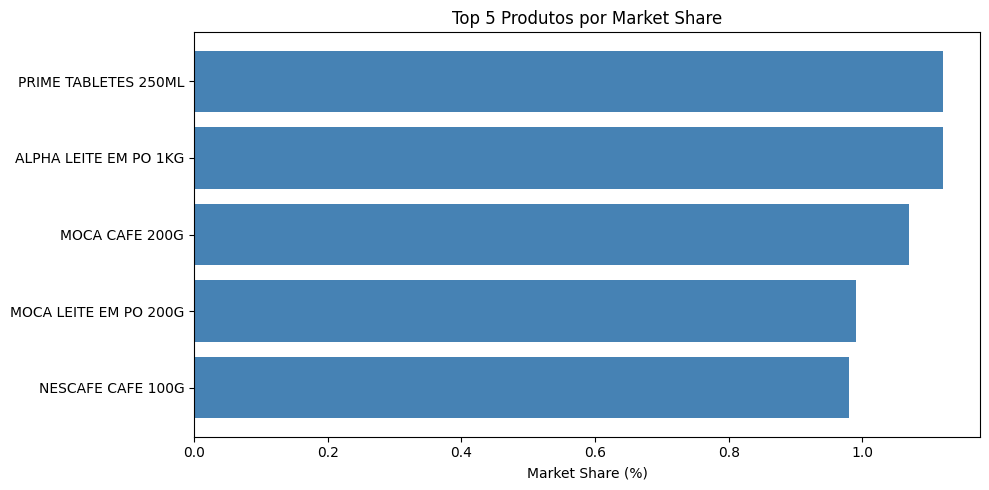

In [0]:
# Top 5 Produtos por Market Share (Table)
df_products = (spark.table("dataquality_challenge.gold.market_share_by_product")
    .filter("year_week = (SELECT MAX(year_week) FROM dataquality_challenge.gold.market_share_by_product)")
    .select("product_description", "brand", "category", "total_sales_brl", "market_share_pct")
    .orderBy("market_share_pct", ascending=False)
    .limit(5))
pdf = df_products.toPandas()
plt.figure(figsize=(10, 5))
plt.barh(pdf["product_description"], pdf["market_share_pct"], color="steelblue")
plt.xlabel("Market Share (%)")
plt.title("Top 5 Produtos por Market Share")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

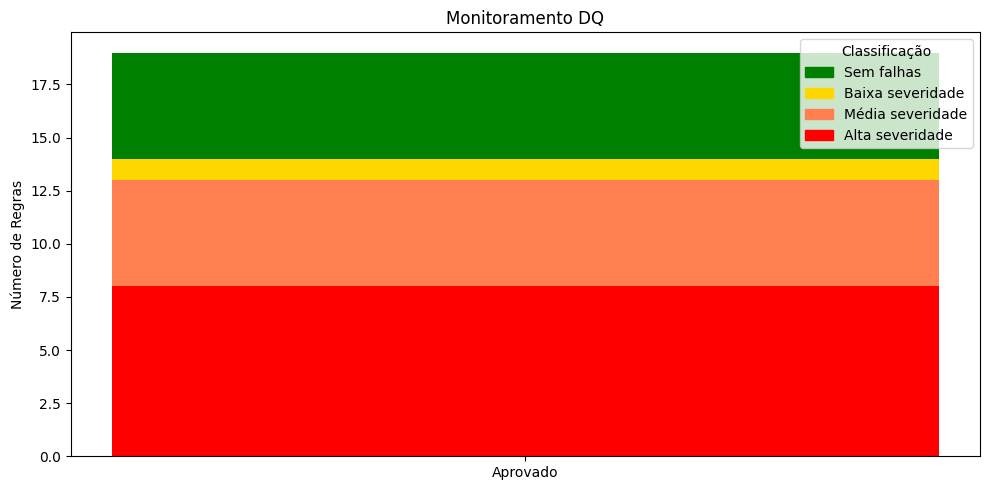

In [0]:
# Monitoramento DQ (Table)
df_dq = (spark.table("dataquality_challenge.gold.dq_monitoring")
    .select("classification", "severity", "rule_count", "total_failures", "avg_percent")
    .orderBy("rule_count", ascending=False))
pdf = df_dq.toPandas()
colors = ["green", "gold", "coral", "red"][:len(pdf)]
plt.figure(figsize=(10, 5))
bars = plt.bar(pdf["classification"], pdf["rule_count"], color=colors)
plt.ylabel("Número de Regras")
plt.title("Monitoramento DQ")
legend_labels = {
    "green": "Sem falhas",
    "gold": "Baixa severidade",
    "coral": "Média severidade",
    "red": "Alta severidade",
}
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in colors]
labels = [legend_labels.get(c, c) for c in colors]
plt.legend(handles, labels, title="Classificação", loc="upper right")
plt.tight_layout()
plt.show()

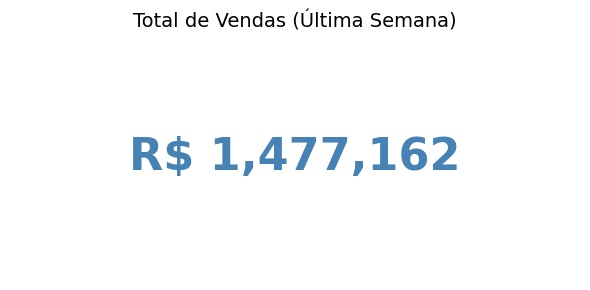

In [0]:
# Total de Vendas (Counter)
df_total = (spark.table("dataquality_challenge.gold.market_share_by_brand")
    .filter("year_week = (SELECT MAX(year_week) FROM dataquality_challenge.gold.market_share_by_brand)")
    .agg(_round(spark_sum("total_sales_brl"), 0).alias("total_sales")))
total = df_total.collect()[0]["total_sales"]
fig, ax = plt.subplots(figsize=(6, 3))
ax.text(0.5, 0.5, f"R$ {total:,.0f}", ha="center", va="center", fontsize=32, fontweight="bold", color="steelblue")
ax.set_title("Total de Vendas (Última Semana)", fontsize=14)
ax.axis("off")
plt.tight_layout()
plt.show()